<a href="https://colab.research.google.com/github/sidvin-ayak/DeepLearning/blob/main/lab3_cnn_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Experiment 3: Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Objective:** To understand the working principle of Convolutional Neural Networks by implementing
convolution, pooling, feature map visualization, and image classification using TensorFlow/Keras.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import time

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1 — Load CIFAR-10



In [2]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", X_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", X_test.shape)
print("Testing labels shape  :", y_test.shape)
print("Number of classes     :", len(class_names))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2057s 12us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000,)
Testing images shape  : (10000, 32, 32, 3)
Testing labels shape  : (10000,)
Number of classes     : 10


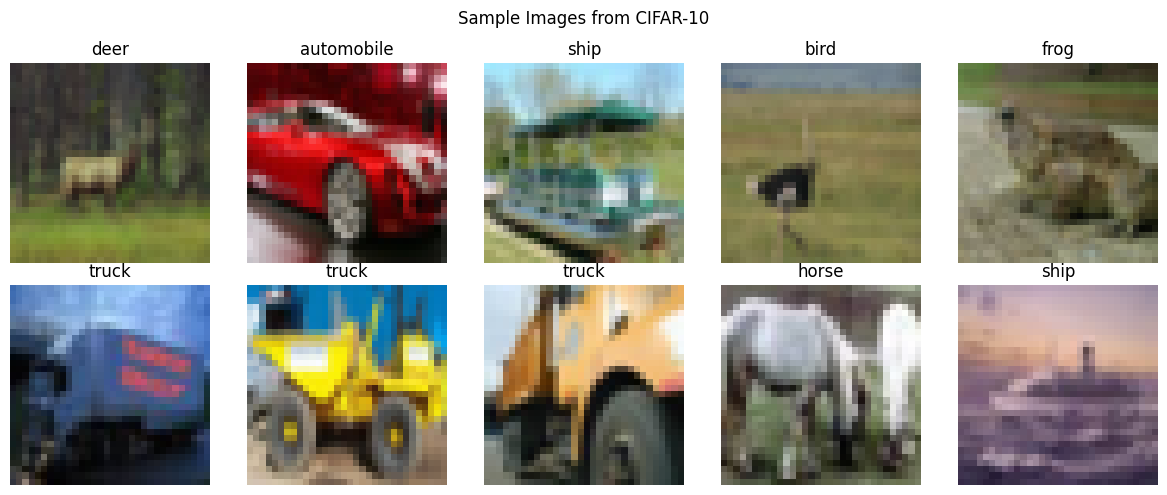

In [3]:
# Display 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_train[idx])
    ax.set_title(class_names[y_train[idx]])
    ax.axis('off')

plt.suptitle("Sample Images from CIFAR-10")
plt.tight_layout()
plt.show()


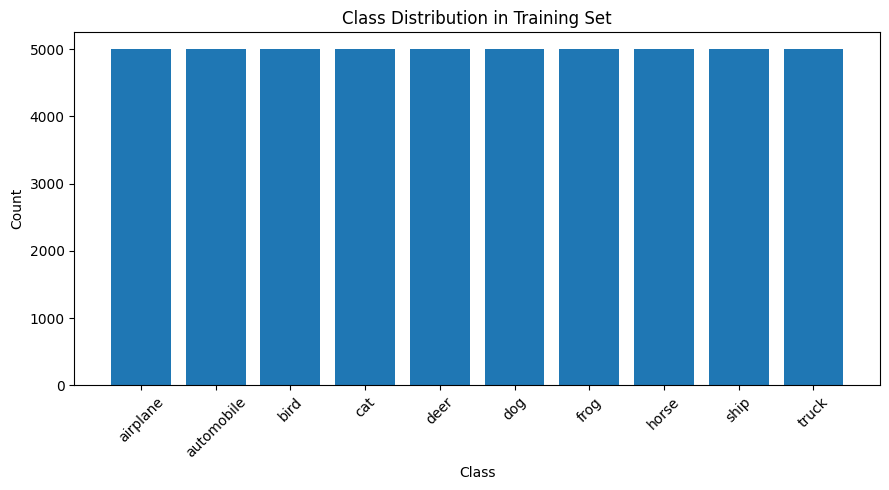

Images per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [4]:
# Plot class distribution in the training set
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(9, 5))
plt.bar([class_names[i] for i in unique], counts, color='#1f77b4')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Images per class:", dict(zip([class_names[i] for i in unique], counts)))


## 3.1 Common Convolution Kernels



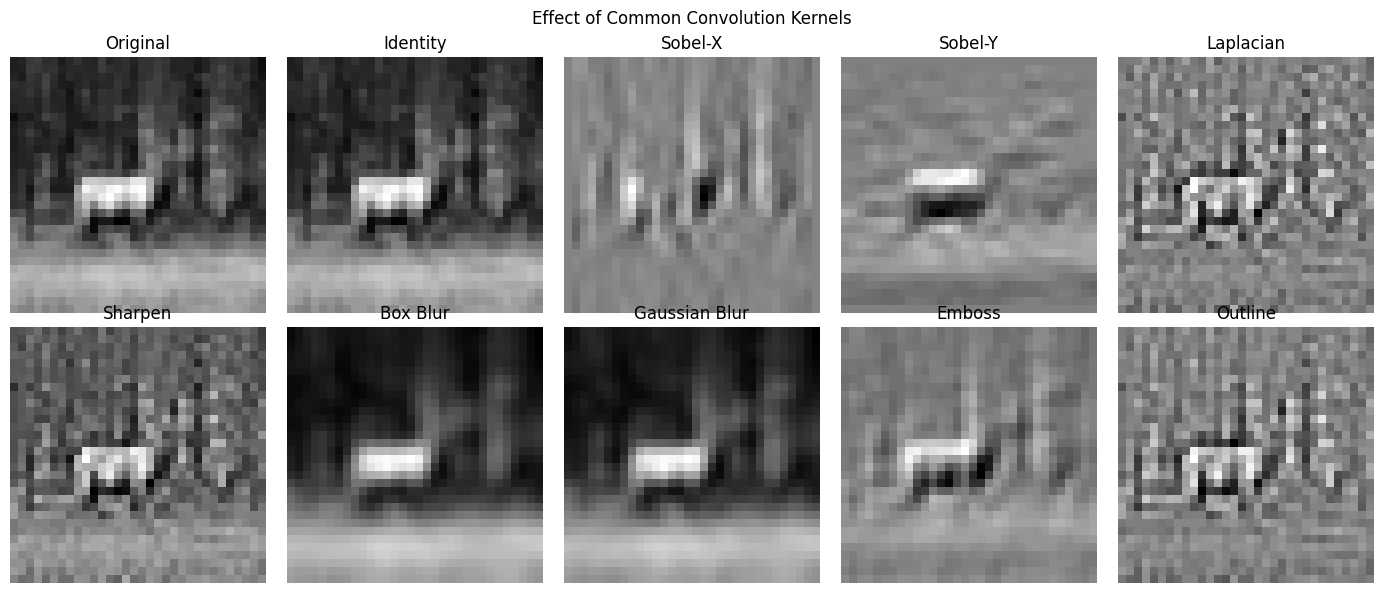

In [5]:
import cv2

kernels = {
    "Identity": np.array([[0,0,0],[0,1,0],[0,0,0]]),
    "Sobel-X": np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    "Sobel-Y": np.array([[-1,-2,-1],[0,0,0],[1,2,1]]),
    "Laplacian": np.array([[0,-1,0],[-1,4,-1],[0,-1,0]]),
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    "Box Blur": (1/9)*np.ones((3,3)),
    "Gaussian Blur": (1/16)*np.array([[1,2,1],[2,4,2],[1,2,1]]),
    "Emboss": np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
    "Outline": np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),
}

sample_gray = cv2.cvtColor(X_train[sample_idx[0]], cv2.COLOR_RGB2GRAY).astype(np.float32)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for ax, (name, k) in zip(axes[1:], kernels.items()):
    filtered = cv2.filter2D(sample_gray, -1, k)
    ax.imshow(filtered, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle("Effect of Common Convolution Kernels")
plt.tight_layout()
plt.show()


## Numerical Examples (verification of theory)

### Example 1 — Convolution
$$X=\begin{bmatrix}1&2&3\\4&5&6\\7&8&9\end{bmatrix}, \quad K=\begin{bmatrix}1&0\\0&1\end{bmatrix}$$


In [6]:
X_ex = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
K_ex = np.array([[1,0],[0,1]], dtype=float)

def conv2d_valid(X, K):
    kh, kw = K.shape
    oh, ow = X.shape[0]-kh+1, X.shape[1]-kw+1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            out[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return out

feature_map = conv2d_valid(X_ex, K_ex)
print("Feature Map:\n", feature_map)


Feature Map:
 [[ 6.  8.]
 [12. 14.]]


### Example 2 — Max Pooling (2×2 window)
$$\begin{bmatrix}1&5&2&3\\7&8&1&0\\4&6&9&5\\2&3&1&8\end{bmatrix}$$


In [7]:
def max_pool2d(X, size=2, stride=2):
    h, w = X.shape
    oh, ow = h // stride, w // stride
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            window = X[i*stride:i*stride+size, j*stride:j*stride+size]
            out[i, j] = np.max(window)
    return out

feat = np.array([[1,5,2,3],[7,8,1,0],[4,6,9,5],[2,3,1,8]], dtype=float)
print("Max-Pooled Output:\n", max_pool2d(feat))


Max-Pooled Output:
 [[8. 3.]
 [6. 9.]]


### Example 3 — Trainable Parameter Calculation
For a 32×32×3 input, Conv2D with 16 filters of size 3×3:
$$\text{Params} = (3\times3\times3 + 1)\times16 = 448$$


In [8]:
params = (3*3*3 + 1) * 16
print("Total trainable parameters:", params)


Total trainable parameters: 448


## Task 2 — Implement a Convolution Layer



In [9]:
def output_size(N, F, P, S):
    return (N - F + 2*P) // S + 1

input_size = 32

print(f"{'Kernel':<10}{'Padding':<10}{'Stride':<8}{'Output Size'}")
for k in [3, 5, 7]:
    # 'same' padding output equals input size for stride 1
    print(f"{k}x{k:<7}{'Same':<10}{1:<8}{input_size}x{input_size}")
for k in [3, 5, 7]:
    P = 0
    out = output_size(input_size, k, P, 1)
    print(f"{k}x{k:<7}{'Valid':<10}{1:<8}{out}x{out}")


Kernel    Padding   Stride  Output Size
3x3      Same      1       32x32
5x5      Same      1       32x32
7x7      Same      1       32x32
3x3      Valid     1       30x30
5x5      Valid     1       28x28
7x7      Valid     1       26x26


In [10]:
# Demonstrate with actual Keras Conv2D layers on a batch of real images
sample_batch = X_train[:1].astype('float32') / 255.0

print(f"{'Kernel':<8}{'Padding':<10}{'Output Shape'}")
for k in [3, 5, 7]:
    for pad in ['same', 'valid']:
        conv = layers.Conv2D(8, (k, k), padding=pad)
        out = conv(sample_batch)
        print(f"{k}x{k:<5}{pad:<10}{out.shape}")


Kernel  Padding   Output Shape
3x3    same      (1, 32, 32, 8)
3x3    valid     (1, 30, 30, 8)
5x5    same      (1, 32, 32, 8)
5x5    valid     (1, 28, 28, 8)
7x7    same      (1, 32, 32, 8)
7x7    valid     (1, 26, 26, 8)


## Task 3 — Study Hyperparameters
Compare stride (1 vs 2) and padding (same vs valid) using the formula
$$\left\lfloor\frac{N-F+2P}{S}\right\rfloor + 1$$
for a 32×32 input and a 3×3 kernel.


In [11]:
print(f"{'Stride':<8}{'Padding':<10}{'P':<4}{'Output Size'}")
configs = [(1, 'same', 1), (1, 'valid', 0), (2, 'same', 1), (2, 'valid', 0)]
for S, pad_name, P in configs:
    out = output_size(32, 3, P, S)
    print(f"{S:<8}{pad_name:<10}{P:<4}{out}x{out}")


Stride  Padding   P   Output Size
1       same      1   32x32
1       valid     0   30x30
2       same      1   16x16
2       valid     0   15x15


In [12]:
# Verify with Keras layers
sample_batch = X_train[:1].astype('float32') / 255.0
print(f"{'Stride':<8}{'Padding':<10}{'Output Shape'}")
for S in [1, 2]:
    for pad in ['same', 'valid']:
        conv = layers.Conv2D(8, (3, 3), strides=S, padding=pad)
        out = conv(sample_batch)
        print(f"{S:<8}{pad:<10}{out.shape}")


Stride  Padding   Output Shape
1       same      (1, 32, 32, 8)
1       valid     (1, 30, 30, 8)
2       same      (1, 16, 16, 8)
2       valid     (1, 15, 15, 8)


In [13]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Hold out a validation split from the training set
val_split = 0.1
n_val = int(len(X_train_norm) * val_split)
X_val, y_val = X_train_norm[:n_val], y_train_cat[:n_val]
X_tr, y_tr = X_train_norm[n_val:], y_train_cat[n_val:]

print("Train:", X_tr.shape, " Val:", X_val.shape, " Test:", X_test_norm.shape)


Train: (45000, 32, 32, 3)  Val: (5000, 32, 32, 3)  Test: (10000, 32, 32, 3)


In [14]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', name='conv2d_1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', name='conv2d_2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', name='conv2d_3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# First conv layer parameter check (32 filters of 3x3x3 -> matches Discussion Q6)
first_conv_params = (3*3*3 + 1) * 32
print("Expected first Conv2D params:", first_conv_params)


Expected first Conv2D params: 896


In [16]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

start = time.time()
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
train_time = time.time() - start
print(f"Training completed in {train_time/60:.2f} minutes")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3282 - loss: 1.7693 - val_accuracy: 0.4788 - val_loss: 1.4192
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4368 - loss: 1.4790 - val_accuracy: 0.5876 - val_loss: 1.1732
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4892 - loss: 1.3514 - val_accuracy: 0.6020 - val_loss: 1.1046
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5200 - loss: 1.2666 - val_accuracy: 0.6232 - val_loss: 1.0449
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5460 - loss: 1.1986 - val_accuracy: 0.6400 - val_loss: 1.0110
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5728 - loss: 1.1366 - val_accuracy: 0.6302 - val_loss: 1.0068
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5849 - loss: 1.0999 - val_accuracy: 0.6764 - val_loss: 0.9091
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6033 - loss: 1.0486 - val_accuracy: 

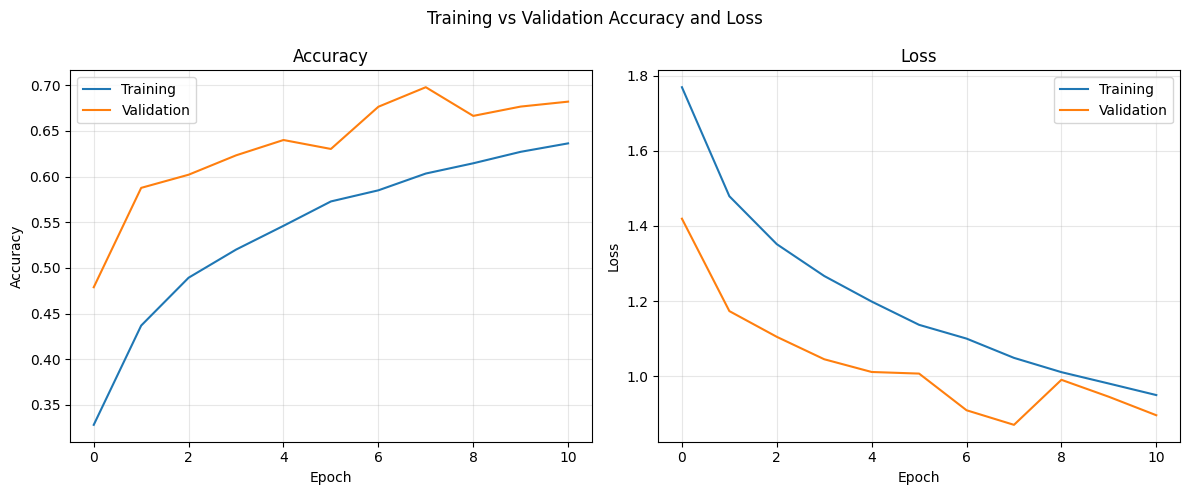

In [17]:
# Training vs Validation Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['accuracy'], label='Training')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training vs Validation Accuracy and Loss')
plt.tight_layout()
plt.show()


## Task 4 — Visualize Feature Maps
Extract and display feature maps from the three convolutional layers (`conv2d_1`, `conv2d_2`, `conv2d_3`)
for a single test image, showing the first 8 channels of each layer's output.


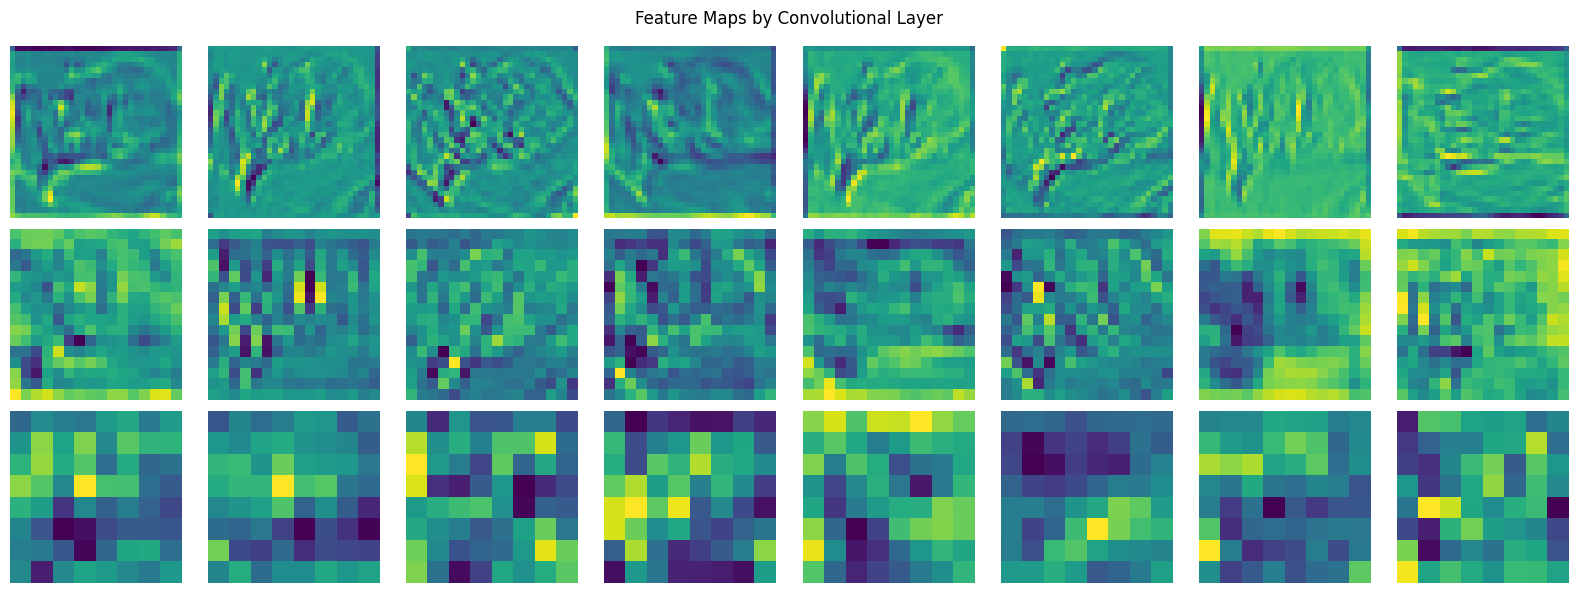

In [18]:
layer_names = ['conv2d_1', 'conv2d_2', 'conv2d_3']
outputs = [model.get_layer(name).output for name in layer_names]
activation_model = models.Model(inputs=model.inputs, outputs=outputs)

test_img = X_test_norm[0:1]
activations = activation_model.predict(test_img, verbose=0)

fig, axes = plt.subplots(len(layer_names), 8, figsize=(16, 6))
for row, (layer_name, activation) in enumerate(zip(layer_names, activations)):
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(activation[0, :, :, col], cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(layer_name, fontsize=9)

plt.suptitle("Feature Maps by Convolutional Layer")
plt.tight_layout()
plt.show()


## Task 5 — Max Pooling vs Average Pooling
Compare output size and (approximate) effect on accuracy for Max Pooling vs Average Pooling, using a
smaller/faster model trained for a few epochs on a subset for a quick empirical comparison.


In [19]:
def output_size_pool(N, F=2, S=2):
    return (N - F) // S + 1

print("Max/Avg Pool 2x2 stride 2 on 32x32 input -> output:",
      output_size_pool(32), "x", output_size_pool(32))


Max/Avg Pool 2x2 stride 2 on 32x32 input -> output: 16 x 16


In [20]:
def build_cnn_pooling(pool_type='max'):
    Pool = layers.MaxPooling2D if pool_type == 'max' else layers.AveragePooling2D
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        Pool((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        Pool((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Quick comparison on a subset for speed
subset = 10000
results = {}
for pool_type in ['max', 'avg']:
    m = build_cnn_pooling(pool_type)
    h = m.fit(X_tr[:subset], y_tr[:subset],
              validation_data=(X_val, y_val),
              epochs=5, batch_size=64, verbose=0)
    val_acc = h.history['val_accuracy'][-1]
    results[pool_type] = val_acc
    print(f"{pool_type.capitalize()} Pooling — final validation accuracy: {val_acc:.4f}")

print("\nComparison:", results)


Max Pooling — final validation accuracy: 0.5544
Avg Pooling — final validation accuracy: 0.5382

Comparison: {'max': 0.5544000267982483, 'avg': 0.5382000207901001}


## Task 7 — Evaluate the Model
Compute Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report on the test set.


In [21]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(X_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nPrecision (weighted): {precision:.4f}")
print(f"Recall (weighted)   : {recall:.4f}")
print(f"F1-score (weighted) : {f1:.4f}")


Test Accuracy: 68.11%
Test Loss: 0.9025

Precision (weighted): 0.6921
Recall (weighted)   : 0.6811
F1-score (weighted) : 0.6741


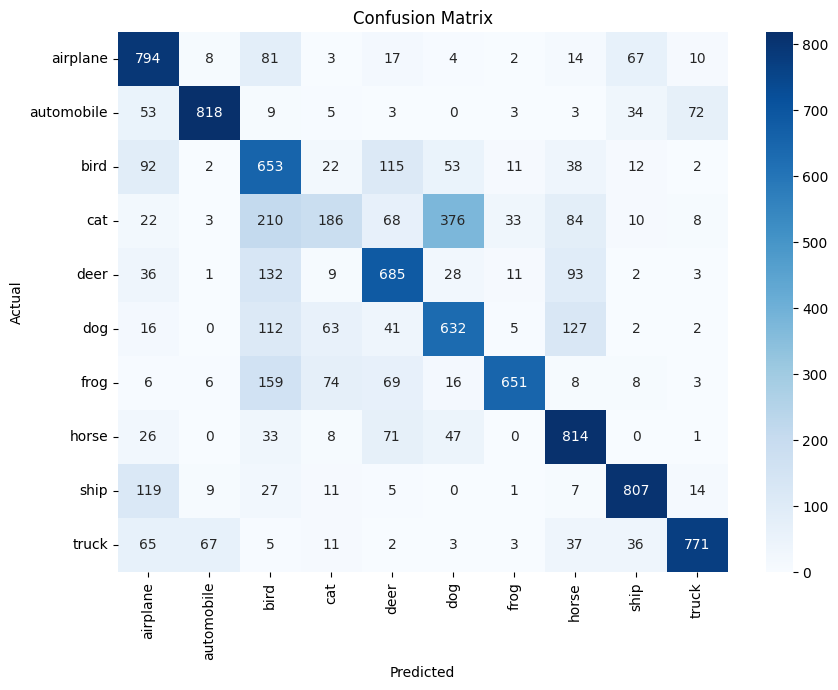

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [23]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

    airplane       0.65      0.79      0.71      1000
  automobile       0.89      0.82      0.85      1000
        bird       0.46      0.65      0.54      1000
         cat       0.47      0.19      0.27      1000
        deer       0.64      0.69      0.66      1000
         dog       0.55      0.63      0.59      1000
        frog       0.90      0.65      0.76      1000
       horse       0.66      0.81      0.73      1000
        ship       0.83      0.81      0.82      1000
       truck       0.87      0.77      0.82      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.67     10000
weighted avg       0.69      0.68      0.67     10000



## 11. Results Summary

In [24]:
print("="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Training Accuracy (final epoch)   : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Accuracy (final epoch) : {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Testing Accuracy                  : {test_acc*100:.2f}%")
print(f"Precision (weighted)              : {precision:.4f}")
print(f"Recall (weighted)                 : {recall:.4f}")
print(f"F1-score (weighted)               : {f1:.4f}")

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
non_trainable_params = total_params - trainable_params
print(f"Total Parameters                  : {total_params}")
print(f"Trainable Parameters              : {int(trainable_params)}")
print(f"Non-trainable Parameters          : {int(non_trainable_params)}")


RESULTS SUMMARY
Training Accuracy (final epoch)   : 63.63%
Validation Accuracy (final epoch) : 68.20%
Testing Accuracy                  : 68.11%
Precision (weighted)              : 0.6921
Recall (weighted)                 : 0.6811
F1-score (weighted)               : 0.6741
Total Parameters                  : 357706
Trainable Parameters              : 357258
Non-trainable Parameters          : 448


## 10. Additional Exercises

In [25]:
# 1. Output size for a 64x64 image, 5x5 kernel, stride 2, padding 2
N, F, P, S = 64, 5, 2, 2
out = (N - F + 2*P)//S + 1
print(f"1. Output size (64x64, 5x5 kernel, stride 2, padding 2): {out}x{out}")

# 2. Trainable parameters for a conv layer with 64 filters of size 3x3, RGB input
params_ex2 = (3*3*3 + 1) * 64
print(f"2. Trainable parameters (64 filters, 3x3, RGB input): {params_ex2}")


1. Output size (64x64, 5x5 kernel, stride 2, padding 2): 32x32
2. Trainable parameters (64 filters, 3x3, RGB input): 1792


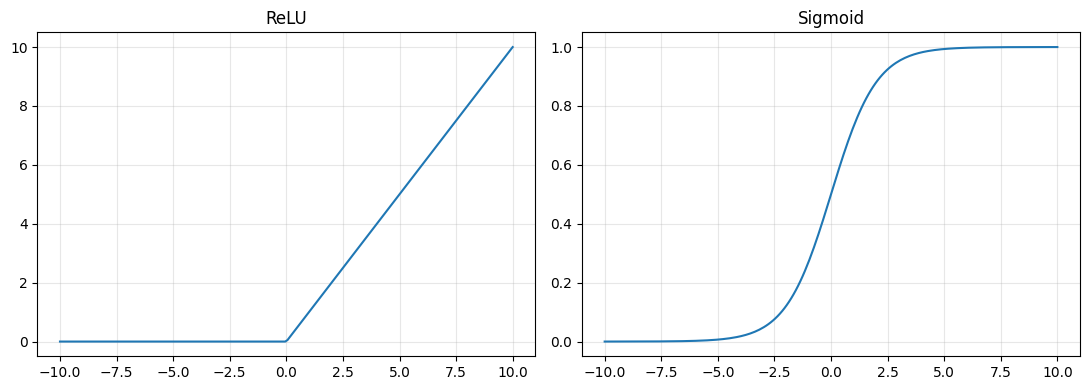

ReLU: f(x)=max(0,x). Computationally cheap, avoids vanishing gradients for x>0,
but can suffer from 'dying ReLU' for x<0. Widely used in hidden layers of CNNs.

Sigmoid: f(x)=1/(1+e^-x). Squashes output to (0,1), useful for binary probabilities,
but saturates for large |x| causing vanishing gradients, and is more expensive to compute.
ReLU is generally preferred in deep CNN hidden layers for faster, more stable training.


In [26]:
# 3. Compare ReLU vs Sigmoid activation functions
x = np.linspace(-10, 10, 200)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, relu)
axes[0].set_title("ReLU")
axes[0].grid(alpha=0.3)
axes[1].plot(x, sigmoid)
axes[1].set_title("Sigmoid")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ReLU: f(x)=max(0,x). Computationally cheap, avoids vanishing gradients for x>0,\n"
      "but can suffer from 'dying ReLU' for x<0. Widely used in hidden layers of CNNs.\n\n"
      "Sigmoid: f(x)=1/(1+e^-x). Squashes output to (0,1), useful for binary probabilities,\n"
      "but saturates for large |x| causing vanishing gradients, and is more expensive to compute.\n"
      "ReLU is generally preferred in deep CNN hidden layers for faster, more stable training.")


In [27]:
# Quick empirical check: 16 vs 64 filters in the first conv layer
def build_cnn_filters(n_filters):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(n_filters, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(n_filters*2, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

subset = 10000
for n_filters in [16, 64]:
    m = build_cnn_filters(n_filters)
    t0 = time.time()
    h = m.fit(X_tr[:subset], y_tr[:subset],
              validation_data=(X_val, y_val),
              epochs=5, batch_size=64, verbose=0)
    elapsed = time.time() - t0
    print(f"Filters={n_filters:<4} Params={m.count_params():<10} "
          f"Val Acc={h.history['val_accuracy'][-1]:.4f}  Time={elapsed:.1f}s")


Filters=16   Params=136874     Val Acc=0.5406  Time=10.3s
Filters=64   Params=600650     Val Acc=0.5874  Time=11.4s


## Save the Trained Model

In [28]:
model.save('cnn_cifar10_model.keras')
print("Model saved as cnn_cifar10_model.keras")


Model saved as cnn_cifar10_model.keras
